### **1.Setup**


In [26]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns
from IPython.display import display

train_path=os.path.join("..","data","raw","train.csv")
test_path=os.path.join("..","data","raw","test.csv")


### **2.Loading Data and First Look**

#### **2.1. Overall First Look**

In [27]:
df_raw= pd.read_csv(train_path,index_col=0,sep=",")
print(f"Rows:{df_raw.shape[0]:,} | Columns:{df_raw.shape[1]}")
df_raw.head()

Rows:6,534 | Columns:38


,Total Bruto,Total Liquido,Total Imp_,Total Portes,Total Desc_ Global,Total Desc_ Linha,Custo,N_ Detalhes,invoice_count_current_purchase,repeat_purchase_90d,...,customer_id,payment_type,salesperson,commercial_zone,transport_method,warehouse,document_series,purchase_date,ID,random_noise
Total a Pagar,,,,,,,,,,,,,,,,,,,,,
558.11,510.90,453.75,104.36,0.0,0.0,57.15,153.099911,4.0,1.0,1,...,660784,Maybe Tomorrow Payment 10,VLOOKUP Master 9,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2024-10-29,10000000,-0.660448
978.80,830.02,795.77,183.03,0.0,0.0,34.25,472.943134,32.0,1.0,1,...,189146,Maybe Tomorrow Payment 7,VLOOKUP Master 1,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 36,Final Excel Warehouse 1,Ctrl Z Series 1,2017-07-08,10000001,0.924510
10.33,12.00,8.40,1.93,0.0,0.0,3.60,6.097485,1.0,1.0,1,...,103940,Maybe Tomorrow Payment 9,VLOOKUP Master 1,Decorative Dashboard Zone 4,NaN,Final Excel Warehouse 1,Ctrl Z Series 3,2019-03-19,10000002,-0.258730
856.83,696.61,696.61,160.22,0.0,0.0,0.00,408.167275,9.0,1.0,0,...,512927,Maybe Tomorrow Payment 7,VLOOKUP Master 4,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 71,Final Excel Warehouse 1,Ctrl Z Series 3,2018-11-10,10000003,1.448402
1616.10,1488.85,1313.90,302.20,0.0,0.0,174.95,485.401864,33.0,1.0,1,...,122356,Maybe Tomorrow Payment 12,NaN,Decorative Dashboard Zone 4,Maybe Tomorrow Delivery 61,Final Excel Warehouse 1,Ctrl Z Series 2,2021-11-30,10000004,-1.058890


In [28]:
#df_raw.info() shows the type of each column
df_raw.info()

<class 'pandas.DataFrame'>
Index: 6534 entries, 558.11 to 951.71
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Total Bruto                     6469 non-null   float64
 1   Total Liquido                   6469 non-null   float64
 2   Total Imp_                      6469 non-null   float64
 3   Total Portes                    6469 non-null   float64
 4   Total Desc_ Global              6469 non-null   float64
 5   Total Desc_ Linha               6469 non-null   float64
 6   Custo                           6469 non-null   float64
 7   N_ Detalhes                     6469 non-null   float64
 8   invoice_count_current_purchase  6469 non-null   float64
 9   repeat_purchase_90d             6534 non-null   int64  
 10  days_since_previous_purchase    5673 non-null   float64
 11  customer_tenure_days            6469 non-null   float64
 12  prior_purchase_count            6469 non-nu

Purchase Date as String is a problem
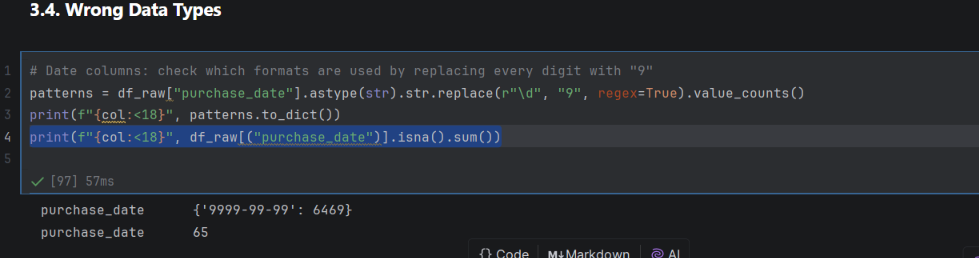

#### **2.2 Grouping the Variables**

To better organize our data we chose to group the variables by themes:

In [30]:
#Variables with special structural roles
target_col = "repeat_purchase_90d"
group_col = "customer_id"
index_col = "ID"

# Grouping by themes
var_groups = {
    "Identifier": [
        "ID",
        "customer_id"
    ],
    "Target": [
        "repeat_purchase_90d"
    ],
    "Current transaction (financial)": [
        "Total a Pagar",
        "Total Bruto",
        "Total Liquido",
        "Total Imp_",
        "Total Portes",
        "Total Desc_ Global",
        "Total Desc_ Linha",
        "Custo"
    ],
    "Current transaction (operational)": [
        "N_ Detalhes",
        "invoice_count_current_purchase"
    ],
    "Transaction context & date": [
        "purchase_date",
        "payment_type",
        "salesperson",
        "commercial_zone",
        "warehouse",
        "document_series",
        "transport_method"
    ],
    "Customer historical summary": [
        "customer_tenure_days",
        "prior_purchase_count",
        "prior_total_spend",
        "prior_mean_purchase_value",
        "prior_std_purchase_value",
        "prior_min_purchase_value",
        "prior_max_purchase_value"
    ],
    "Customer cadence & gaps": [
        "days_since_previous_purchase",
        "prior_mean_gap_days",
        "prior_std_gap_days"
    ],
    "Rolling windows (RFM)": [
        "purchase_count_30d",
        "spend_30d",
        "purchase_count_90d",
        "spend_90d",
        "purchase_count_180d",
        "spend_180d",
        "purchase_count_365d",
        "spend_365d"
    ],
    "Synthetic / Control": [
        "random_noise"
    ]
}
pd.DataFrame(
    [(group, len(cols), ", ".join(cols)) for group, cols in var_groups.items()], columns=["Group", "# vars", "Variables"])

,Group,# vars,Variables
0,Identifier,2,"ID, customer_id"
1,Target,1,repeat_purchase_90d
2,Current transaction (financial),8,"Total a Pagar, Total Bruto, Total Liquido, Tot..."
3,Current transaction (operational),2,"N_ Detalhes, invoice_count_current_purchase"
4,Transaction context & date,7,"purchase_date, payment_type, salesperson, comm..."
5,Customer historical summary,7,"customer_tenure_days, prior_purchase_count, pr..."
6,Customer cadence & gaps,3,"days_since_previous_purchase, prior_mean_gap_d..."
7,Rolling windows (RFM),8,"purchase_count_30d, spend_30d, purchase_count_..."
8,Synthetic / Control,1,random_noise


###  **3. Data Quality Assessment**

  Before changing anything, we first diagnose the problems.

#### **3.1.Duplicates**

In [25]:
n_dup_rows=df_raw.duplicated().sum()  #rows that are 100% identical
n_dup_ids=df_raw["customer_id"].duplicated().sum() #repeated member IDs
n_client_ids= df_raw["customer_id"].nunique()
print(f"Fully duplicated rows : {n_dup_rows}")
print(f"Duplicated client_id  : {n_dup_ids}")
print(f"Number of clients : {n_client_ids}")
print(f"Number of receipts/clients: {(n_dup_ids/n_client_ids).round(2)}")

Fully duplicated rows : 0
Duplicated client_id  : 5924
Number of clients : 610
Number of receipts/clients: 9.71


From this, we can conclude that there are no fully duplicated rows, ensuring that no records were duplicated due to input errors. We can also conclude that there are 6,534 records distributed across only 610 unique clients. This yields an average of approximately 9.7 transactions per client, validating the robustness of our database to feed a predictive model for 90-day repeat purchases.

#### **3.2.Missing Values**

In [44]:
missing_values=(df_raw.isna().sum().to_frame("n_missing").assign(percentage=lambda x: (x["n_missing"]*100/len(df_raw))).query("n_missing>0").sort_values("percentage", ascending=False))
missing_values

,n_missing,percentage
prior_std_gap_days,1478,22.620141
prior_mean_gap_days,1308,20.018365
prior_std_purchase_value,1113,17.033976
prior_mean_purchase_value,862,13.192531
days_since_previous_purchase,861,13.177227
prior_min_purchase_value,668,10.223447
prior_max_purchase_value,668,10.223447
transport_method,261,3.994490
warehouse,260,3.979186
spend_365d,260,3.979186


Identificamos que todas as colunas à exceção da coluna ID têm missing values.Há uma consistência em todas as colunas que é a ausência de 65 linhas. Verificamos tmb que há colunas com **pelo menos 20% de MVs**. Pode fazer sentido, caso haja colunas com forte correlação com estas, dropar as colunas.

In [68]:
row_missing_percentage = pd.DataFrame({
    'customer_id': df_raw['customer_id'],
    'n_missing': df_raw.isna().sum(axis=1),
    'pct_missing': (df_raw.isna().sum(axis=1) * 100) / df_raw.shape[1]})

row_missing_percentage = (
    row_missing_percentage
    .set_index("customer_id")
    .query("n_missing > 19")
    .sort_values("n_missing", ascending=False))

print(f"There are {row_missing_percentage.shape[0]} rows with at least 50% of missing values")
row_missing_percentage


There are 65 rows with at least 50% of missing values


,n_missing,pct_missing
customer_id,,
755628,35,92.105263
755628,35,92.105263
427118,35,92.105263
508217,35,92.105263
427118,35,92.105263
...,...,...
151492,35,92.105263
230585,35,92.105263
902830,35,92.105263


Procurámos também saber a percentagem de Missing Values por Linha para avaliar a percentagem de informação que cada linha nos pode dar. Entendemos que existem 65 linhas com percentagem de Missing Values maior que 50% e por isso **consideramos descartáveis por não nos dar informações suficientes**.

#### **3.3. Inconsistent Categories**

In [70]:
cat_cols = df_raw.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
for col in cat_cols:
    print(f"{col:<10} -> {df_raw[col].nunique()} distinct values")

payment_type -> 9 distinct values
salesperson -> 9 distinct values
commercial_zone -> 5 distinct values
transport_method -> 80 distinct values
warehouse  -> 2 distinct values
document_series -> 3 distinct values
purchase_date -> 1492 distinct values


The same category is written in many different ways. This will create us a problem in the future. Lets analyse which columns need to be trimmed.

In [71]:
df_raw["payment_type"].value_counts(dropna=False)

payment_type
Maybe Tomorrow Payment 7     4565
Maybe Tomorrow Payment 12     991
Maybe Tomorrow Payment 9      502
NaN                           260
Maybe Tomorrow Payment 10     134
Maybe Tomorrow Payment 8       40
Maybe Tomorrow Payment 2       21
Maybe Tomorrow Payment 4        9
Maybe Tomorrow Payment 11       8
Maybe Tomorrow Payment 3        4
Name: count, dtype: int64

In [72]:
df_raw[("salesperson")].value_counts(dropna=False)


salesperson
VLOOKUP Master 1    4054
VLOOKUP Master 4    1461
VLOOKUP Master 9     384
NaN                  259
VLOOKUP Master 7     201
VLOOKUP Master 2     123
VLOOKUP Master 3      30
VLOOKUP Master 6      12
VLOOKUP Master 5       7
VLOOKUP Master 8       3
Name: count, dtype: int64

In [73]:
df_raw[("commercial_zone")].value_counts(dropna=False)

commercial_zone
Decorative Dashboard Zone 4    6260
Decorative Dashboard Zone 2     151
NaN                              65
Decorative Dashboard Zone 3      56
Decorative Dashboard Zone 6       1
Decorative Dashboard Zone 7       1
Name: count, dtype: int64

Esta categoria está bem.

In [88]:
df_raw["transport_method"].isna().sum()
print(f"There are {df_raw["transport_method"].isna().sum()} NaNs in this category")
df_raw["transport_method"].value_counts(dropna=False)



There are 261 NaNs in this category


transport_method
Maybe Tomorrow Delivery 72    1119
Maybe Tomorrow Delivery 61     627
Maybe Tomorrow Delivery 73     445
Maybe Tomorrow Delivery 59     373
Maybe Tomorrow Delivery 80     319
                              ... 
Maybe Tomorrow Delivery 55       1
Maybe Tomorrow Delivery 58       1
Maybe Tomorrow Delivery 28       1
Maybe Tomorrow Delivery 21       1
Maybe Tomorrow Delivery 23       1
Name: count, Length: 81, dtype: int64

In [75]:
df_raw[("warehouse")].value_counts(dropna=False)


warehouse
Final Excel Warehouse 1    6253
NaN                         260
Final Excel Warehouse 3      21
Name: count, dtype: int64

In [82]:
df_raw[("document_series")].value_counts(dropna=False)

document_series
Ctrl Z Series 2    2738
Ctrl Z Series 3    1903
Ctrl Z Series 1    1828
NaN                  65
Name: count, dtype: int64

In [83]:
df_raw[("purchase_date")].value_counts(dropna=False)

purchase_date
NaN           65
2015-10-31    52
2018-08-05    46
2016-07-17    42
2015-07-12    41
              ..
2021-09-03     1
2024-01-14     1
2023-09-11     1
2022-02-18     1
2024-03-13     1
Name: count, Length: 1493, dtype: int64

#### **3.4. Wrong Data Types**

In [99]:
# Date columns: check which formats are used by replacing every digit with "9"
patterns = df_raw["purchase_date"].astype(str).str.replace(r"\d", "9", regex=True).value_counts()
print(f"{"date format":<18}", patterns.to_dict())
print(f"{"missing values":<18}", df_raw[("purchase_date")].isna().sum())


date format        {'9999-99-99': 6469}
missing values     65


The dates are all in the format 9999-99-99 and we identified 65 NaNs.